<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_Battery_Capacity_Estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Battery Capactity Estimation

**Engineer:** Katherine Mullins

**Completion Date:** 10/03/2026

**Class:** EGN3443

**Assignment #:** 7

**Tool Used:** Colab / Python

## Problem Description

The objective of this analysis is to evaluate TechPower Industries' claim that its battery model has an average capacity of 75 kWh. A random sample of 30 batteries was tested under standard conditions.

The sample will be used to estimate the population mean and standard deviation, construct confidence intervals at multiple confidence levels, and visually examine the distribution of battery capacities. The results will then be compared with the stated 75 kWh specification to determine whether the sample data support the manufacturer’s claim.

## Methodology

Python was used to analyze the 30 battery-capacity measurements. The sample mean was calculated as the point estimate of the population mean, while the sample standard deviation was used as the estimate of population variability.

Because the population standard deviation was unknown, t-based confidence intervals were calculated for the true mean at the 90%, 95%, and 99% confidence levels. The manufacturer's claimed value of 75 kWh was then compared with each interval. A histogram, box plot, and confidence-interval comparison plot were created to evaluate the center, spread, and consistency of the observed measurements.

# Battery Capacity Estimation

This analysis evaluates the battery capacity of 30 lithium-ion batteries produced by TechPower Industries. The company claims that its new battery model has an average capacity of 75 kWh.

The sample data will be used to estimate the population mean and standard deviation, construct confidence intervals, evaluate the 75 kWh claim, and visualize the distribution of battery capacities.

In [1]:
# Step 2: Import data and point estimates
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

battery_capacity_data = [
    74.2, 75.8, 73.9, 76.1, 74.5,
    75.3, 74.8, 73.5, 75.9, 74.6,
    75.2, 74.1, 76.3, 73.8, 75.5,
    74.9, 75.1, 74.3, 75.7, 73.6,
    74.7, 75.4, 74.0, 75.6, 74.4,
    75.0, 73.7, 76.0, 74.8, 75.2
]

data = np.array(battery_capacity_data)

n = len(data)
mean = np.mean(data)
std_dev = np.std(data, ddof=1)
std_error = std_dev / np.sqrt(n)

print("Number of batteries:", n)
print(f"Sample mean: {mean:.3f} kWh")
print(f"Sample standard deviation: {std_dev:.3f} kWh")
print(f"Standard error: {std_error:.3f} kWh")
print(f"Minimum: {np.min(data):.1f} kWh")
print(f"Maximum: {np.max(data):.1f} kWh")

Number of batteries: 30
Sample mean: 74.863 kWh
Sample standard deviation: 0.802 kWh
Standard error: 0.146 kWh
Minimum: 73.5 kWh
Maximum: 76.3 kWh


## Confidence Interval Analysis

Because the population standard deviation is unknown, the sample standard deviation is used to estimate it. A t-distribution is used to construct confidence intervals for the population mean.

Confidence intervals are calculated at the 90%, 95%, and 99% confidence levels and compared with the manufacturer's claimed mean capacity of 75 kWh.

90% CI: 74.614 to 75.112 kWh
95% CI: 74.564 to 75.163 kWh
99% CI: 74.460 to 75.267 kWh


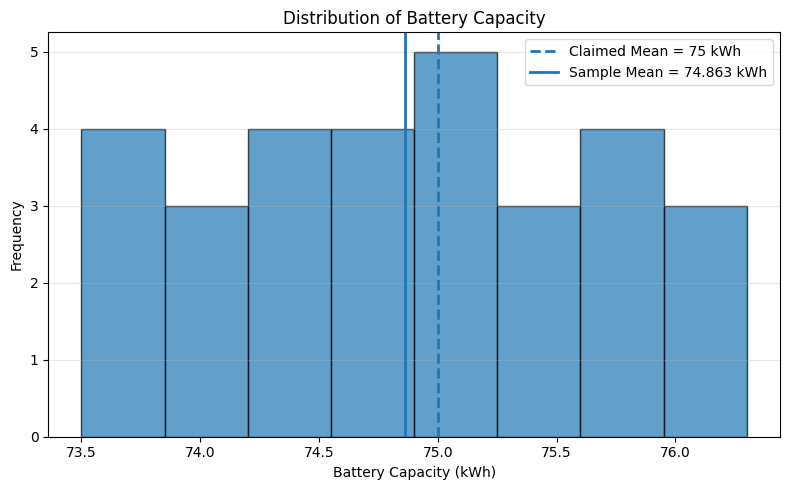

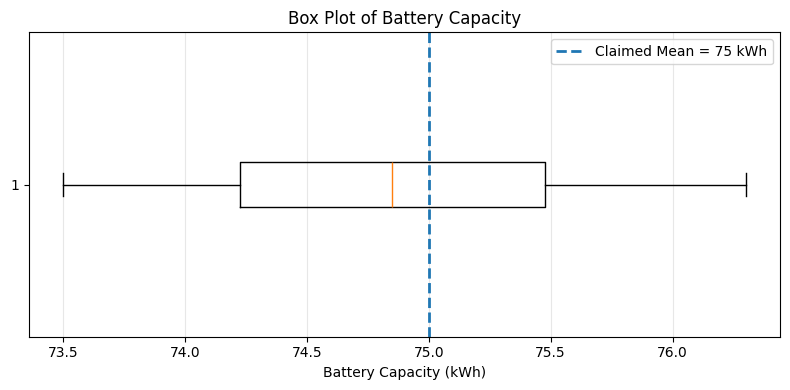

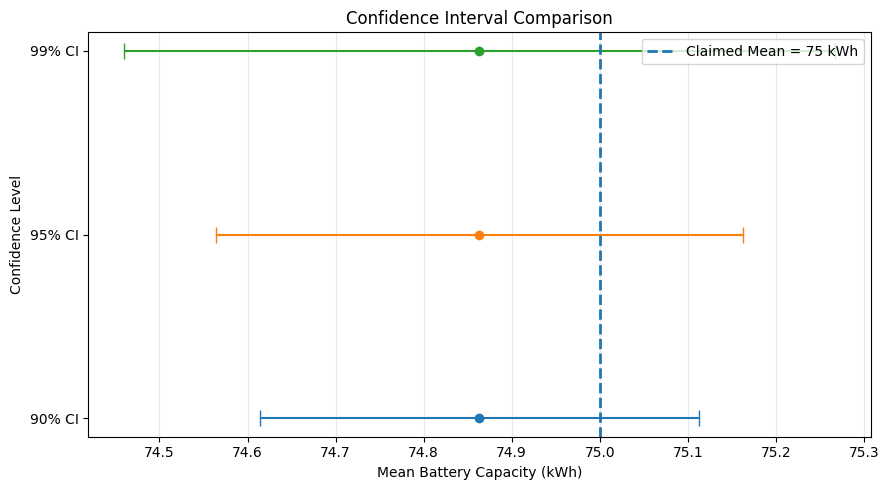

In [2]:
# Step 3: Confidence intervals
confidence_levels = [0.90, 0.95, 0.99]

intervals = []

for confidence in confidence_levels:
    alpha = 1 - confidence

    t_critical = stats.t.ppf(
        1 - alpha / 2,
        df=n - 1
    )

    margin_error = t_critical * std_error

    lower = mean - margin_error
    upper = mean + margin_error

    intervals.append((lower, upper))

    print(
        f"{confidence*100:.0f}% CI: "
        f"{lower:.3f} to {upper:.3f} kWh"
    )

# Step 4: Histogram
plt.figure(figsize=(8, 5))

plt.hist(
    data,
    bins=8,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    75,
    linestyle="--",
    linewidth=2,
    label="Claimed Mean = 75 kWh"
)

plt.axvline(
    mean,
    linestyle="-",
    linewidth=2,
    label=f"Sample Mean = {mean:.3f} kWh"
)

plt.title("Distribution of Battery Capacity")
plt.xlabel("Battery Capacity (kWh)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Step 5: Box Plot
plt.figure(figsize=(8, 4))

plt.boxplot(
    data,
    vert=False
)

plt.axvline(
    75,
    linestyle="--",
    linewidth=2,
    label="Claimed Mean = 75 kWh"
)

plt.title("Box Plot of Battery Capacity")
plt.xlabel("Battery Capacity (kWh)")

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Confidence interval comparison
plt.figure(figsize=(9, 5))

labels = ["90% CI", "95% CI", "99% CI"]

for i, (lower, upper) in enumerate(intervals):

    center = mean

    plt.errorbar(
        center,
        i,
        xerr=[[center - lower], [upper - center]],
        fmt="o",
        capsize=6
    )

plt.axvline(
    75,
    linestyle="--",
    linewidth=2,
    label="Claimed Mean = 75 kWh"
)

plt.yticks(range(len(labels)), labels)

plt.title("Confidence Interval Comparison")
plt.xlabel("Mean Battery Capacity (kWh)")
plt.ylabel("Confidence Level")

plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
